# Coastal Water Quality, Notebook 04: Absolute Turbidity (FNU)

> Terms are defined in [`GLOSSARY.md`](./GLOSSARY.md). This notebook follows
> [`03_water_quality.ipynb`](./03_water_quality.ipynb), which maps relative turbidity.

**Scene:** `20250302_030003_92_4001`, Borneo / Makassar Strait coast.

## Purpose

Notebook 03 maps where water is more turbid. This notebook estimates turbidity in **FNU**
(Formazin Nephelometric Units) with the published Nechad/Dogliotti method used by ACOLITE.
The fixed, multi-site coefficients provide real units without local field measurements.

## Caveats

1. This implements the algorithm, not ACOLITE. ACOLITE does not yet support Tanager, so the
   equations and published coefficients are applied directly.
2. Tanager surface reflectance uses ISOFIT, a land atmospheric correction. A SWIR de-glint
   step partly corrects residual glint and haze but is not a water-specific correction.
3. The estimates are quasi-absolute and not field-validated. Treat the spatial pattern and
   order of magnitude as more reliable than exact values.

## Steps

1. Read the required bands and Planet reflectance uncertainty.
2. Resample Tanager bands to the red and NIR bands used by the coefficients.
3. Apply SWIR de-glinting.
4. Apply the Nechad/Dogliotti red-to-NIR switch to estimate FNU.
5. Propagate measurement uncertainty and compare the result with Notebook 03.


## 0. Setup, coefficients, and bands

The calculation reads only the required HDF5 bands. It uses red near 645 nm, NIR near 859 nm,
SWIR near 1600 nm for de-glinting, green and NIR for the water mask, and Planet's
`surface_reflectance_uncertainty` layer.

| Band | A (scale, FNU) | C (saturation reflectance) |
|---|---:|---:|
| red 645 nm | 228.1 | 0.1641 |
| NIR 859 nm | 3078.9 | 0.2112 |


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.stats import spearmanr

def find_root(start=Path.cwd()):
    p = start.resolve()
    for c in [p, *p.parents]:
        if (c / "data" / "inventory").exists():
            return c
    return p

PROJECT_ROOT = find_root()
SCENE_ID = "20250302_030003_92_4001"
DATA_DIR = PROJECT_ROOT / "data" / "coastal" / SCENE_ID
FIG_DIR  = PROJECT_ROOT / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
SR_PATH  = DATA_DIR / "ortho_sr_hdf5.h5"
DF, FILL = "HDFEOS/GRIDS/HYP/Data Fields", -9999.0
assert SR_PATH.exists(), f"Missing {SR_PATH} - run: python scripts/download_coastal.py --hdf5"

# Dogliotti et al. (2015) turbidity coefficients (MODIS red 645 / NIR 859 nm)
A_RED, C_RED = 228.1, 0.1641
A_NIR, C_NIR = 3078.9, 0.2112
BLEND_LO, BLEND_HI = 0.05, 0.07     # rho_w(645) limits for the red<->NIR switch (Dogliotti 2015)

with h5py.File(SR_PATH, "r") as f:
    SR = f[f"{DF}/surface_reflectance"]; UN = f[f"{DF}/surface_reflectance_uncertainty"]
    WL = np.asarray(SR.attrs["wavelengths"], float); GW = np.asarray(SR.attrs["good_wavelengths"]).astype(bool)
    def window(lo, hi):
        "Indices of GOOD Tanager bands inside a wavelength window (for resampling to a broad band)."
        return np.where((WL >= lo) & (WL <= hi) & GW)[0]
    def bandmean(ds, idx):
        a = ds[idx, :, :].astype("float32"); a[a == FILL] = np.nan; return np.nanmean(a, axis=0)
    i_red, i_nir, i_swir, i_grn = window(620,670), window(841,876), window(1600,1620), window(558,562)
    rho_red  = bandmean(SR, i_red);  rho_nir = bandmean(SR, i_nir)
    rho_swir = bandmean(SR, i_swir); rho_grn = bandmean(SR, i_grn)
    un_red   = bandmean(UN, i_red);  un_nir  = bandmean(UN, i_nir)
    nodata = f[f"{DF}/nodata_pixels"][:]; cloud = f[f"{DF}/beta_cloud_mask"][:]; cirrus = f[f"{DF}/beta_cirrus_mask"][:]

ndwi  = (rho_grn - rho_nir) / (rho_grn + rho_nir)
water = (nodata == 0) & (cloud == 0) & (cirrus == 0) & np.isfinite(rho_red) & (ndwi > 0)
def wonly(a): return np.where(water, a, np.nan)
print(f"water pixels: {int(water.sum()):,}")
print(f"resampled bands -> red {WL[i_red][0]:.0f}-{WL[i_red][-1]:.0f}nm ({len(i_red)} Tanager bands), "
      f"NIR {WL[i_nir][0]:.0f}-{WL[i_nir][-1]:.0f}nm ({len(i_nir)}), SWIR {WL[i_swir][0]:.0f}-{WL[i_swir][-1]:.0f}nm ({len(i_swir)})")


ipykernel_51528\3610570331.py:35: RuntimeWarning: Mean of empty slice
  a = ds[idx, :, :].astype("float32"); a[a == FILL] = np.nan; return np.nanmean(a, axis=0)


water pixels: 208,730
resampled bands -> red 621-666nm (10 Tanager bands), NIR 841-871nm (7), SWIR 1603-1618nm (4)


## 1. Spectral resampling

The published coefficients target broad MODIS red (about 620 to 670 nm) and NIR (about 841 to
876 nm) bands. Tanager has narrow bands across these ranges, so the calculation averages the
valid Tanager bands in each window. The result is comparable to the bands used to calibrate the
coefficients.


Over water:
  rho_red(645): p5/median/p95 = 0.011 / 0.018 / 0.071
  rho_NIR(859): p5/median/p95 = 0.005 / 0.009 / 0.016


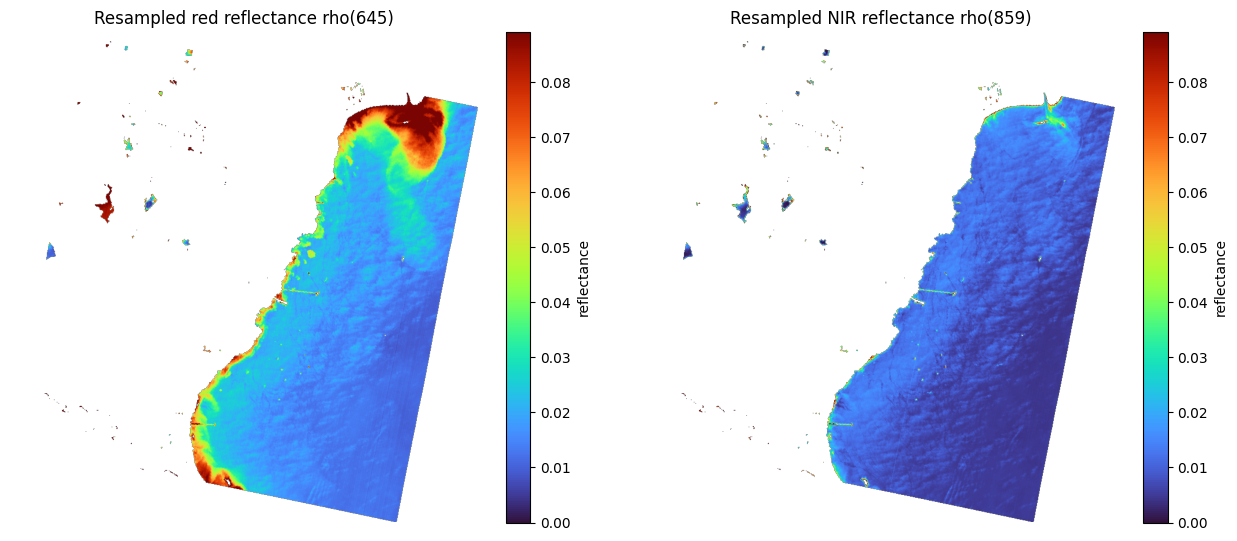

saved -> figures/04_resampled_bands.png


In [2]:
print("Over water:")
for name, a in [("rho_red(645)", rho_red), ("rho_NIR(859)", rho_nir)]:
    v = a[water]
    print(f"  {name}: p5/median/p95 = {np.nanpercentile(v,5):.3f} / {np.nanmedian(v):.3f} / {np.nanpercentile(v,95):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
for a, (img, ttl) in zip(ax, [(wonly(rho_red), "Resampled red reflectance rho(645)"),
                               (wonly(rho_nir), "Resampled NIR reflectance rho(859)")]):
    im = a.imshow(img, cmap="turbo", vmin=0, vmax=np.nanpercentile(rho_red[water], 98))
    a.set_title(ttl); a.axis("off"); fig.colorbar(im, ax=a, fraction=0.046, label="reflectance")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_resampled_bands.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "04_resampled_bands.png")


## 2. SWIR de-glinting

ISOFIT corrects the Tanager scene for land. Over water, residual glint and haze can add a small
nearly uniform reflectance offset. Water is effectively black near 1600 nm, so the observed SWIR
reflectance estimates that offset. The calculation subtracts it from the red and NIR bands. This
is a partial correction, not a replacement for water atmospheric correction.


In [3]:
offset = rho_swir                              # glint/haze residual (water is black at 1600 nm)
rho_red_c = np.clip(rho_red - offset, 0, None)
rho_nir_c = np.clip(rho_nir - offset, 0, None)
print(f"SWIR offset over water: median={np.nanmedian(offset[water]):.4f}, p95={np.nanpercentile(offset[water],95):.4f}")
print(f"red reflectance change: median {np.nanmedian(rho_red[water]):.4f} -> {np.nanmedian(rho_red_c[water]):.4f}")


SWIR offset over water: median=0.0042, p95=0.0097
red reflectance change: median 0.0183 -> 0.0130


**Reference used here**

- Hedley, J.D., Harborne, A.R., & Mumby, P.J. (2005). *Simple and robust removal of sun glint for mapping
  shallow-water benthos.* International Journal of Remote Sensing, 26(10), 2107–2112.
  https://doi.org/10.1080/01431160500034086. The SWIR band estimates the glint and residual offset
  that is subtracted from the visible and NIR bands.


## 3. Nechad/Dogliotti turbidity in FNU

For one band, the method is `T = A * rho / (1 - rho/C)`, where `rho` is de-glinted water
reflectance, `A` sets the FNU scale, and `C` is the saturation reflectance. The method uses red
below rho(645) = 0.05, NIR above 0.07, and a linear blend between them. Pixels near saturation
are flagged because the retrieval is outside its valid range.


Turbidity (FNU) over valid water: p5/median/p95 = 2.4 / 3.2 / 23.6
  max (valid): 544 FNU   |  pixels using mostly NIR: 5.50% (11,489/208,720)
  flagged saturated/out-of-range: 10 px (0.00% of water)


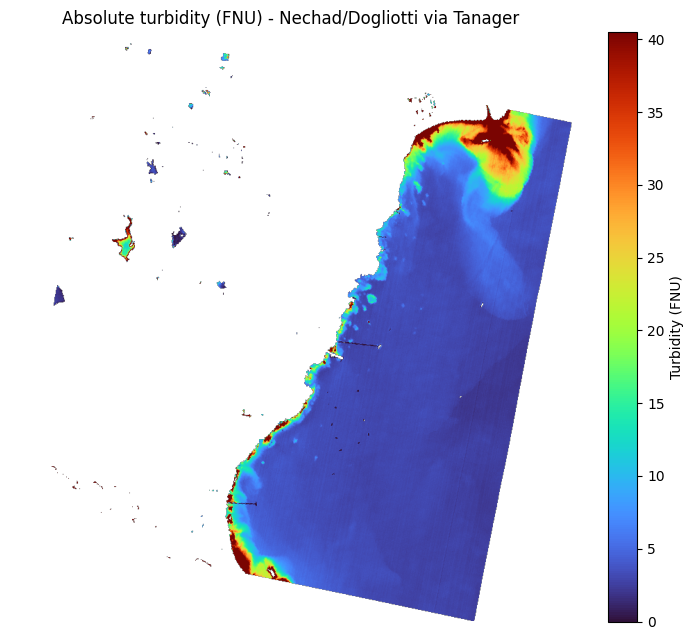

saved -> figures/04_turbidity_fnu.png


In [4]:
def single_band_T(rho, A, C):
    rho_s = np.clip(rho, 0, 0.9 * C)           # keep inside the valid domain (rho < C)
    return A * rho_s / (1 - rho_s / C)

T_red = single_band_T(rho_red_c, A_RED, C_RED)
T_nir = single_band_T(rho_nir_c, A_NIR, C_NIR)
w_nir = np.clip((rho_red_c - BLEND_LO) / (BLEND_HI - BLEND_LO), 0, 1)   # 0=all red, 1=all NIR
turbidity = (1 - w_nir) * T_red + w_nir * T_nir

# flag pixels outside the algorithm's valid range (reflectance near saturation -> unreliable)
saturated = water & ((rho_red_c > 0.9 * C_RED) | (rho_nir_c > 0.9 * C_NIR))
valid_water = water & ~saturated
turb = np.where(valid_water, turbidity, np.nan)

v = turb[np.isfinite(turb)]
mostly_nir_count = int(np.sum(valid_water & (w_nir > 0.5)))
valid_water_count = int(np.sum(valid_water))
print(f"Turbidity (FNU) over valid water: p5/median/p95 = {np.percentile(v,5):.1f} / {np.median(v):.1f} / {np.percentile(v,95):.1f}")
print(f"  max (valid): {v.max():.0f} FNU   |  pixels using mostly NIR: "
      f"{100 * mostly_nir_count / valid_water_count:.2f}% "
      f"({mostly_nir_count:,}/{valid_water_count:,})")
print(f"  flagged saturated/out-of-range: {int(saturated.sum())} px ({100*saturated.sum()/water.sum():.2f}% of water)")

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(turb, cmap="turbo", vmin=0, vmax=np.nanpercentile(v, 98))
ax.set_title("Absolute turbidity (FNU) - Nechad/Dogliotti via Tanager"); ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, label="Turbidity (FNU)")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_turbidity_fnu.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "04_turbidity_fnu.png")


**References used here**

- Nechad, B., Ruddick, K.G., & Park, Y. (2010). *Calibration and validation of a generic multisensor algorithm for
  mapping of total suspended matter in turbid waters.* Remote Sensing of Environment, 114(4), 854–866.
  https://doi.org/10.1016/j.rse.2009.11.022. This provides the `T = A*rho/(1 - rho/C)` form.
- Dogliotti, A.I., Ruddick, K.G., Nechad, B., Doxaran, D., & Knaeps, E. (2015). *A single algorithm to retrieve
  turbidity from remotely-sensed data in all coastal and estuarine waters.* Remote Sensing of Environment, 156,
  157–168. https://doi.org/10.1016/j.rse.2014.09.020. This provides the red-to-NIR switch and the
  published A/C coefficients: 645 nm A=228.1, C=0.1641; 859 nm A=3078.9, C=0.2112; blend over rho(645)=0.05–0.07.
- Vanhellemont, Q., & Ruddick, K. (2018). *Atmospheric correction of metre-scale optical satellite data for inland
  and coastal water applications.* Remote Sensing of Environment, 216, 586–597.
  https://doi.org/10.1016/j.rse.2018.07.015. ACOLITE applies this turbidity algorithm operationally.


## 4. Uncertainty

Planet provides `surface_reflectance_uncertainty` for each pixel. The calculation propagates this
measurement uncertainty through the turbidity equation. It does not include uncertainty from the
generic coefficients, land atmospheric correction, or the lack of local validation. Read the map
as a measurement-noise floor, not the total error.


Planet reflectance uncertainty (red), median over water: 0.0004
-> turbidity measurement-noise uncertainty: median 4% (NOTE: excludes the much larger coefficient + atmospheric-correction error)


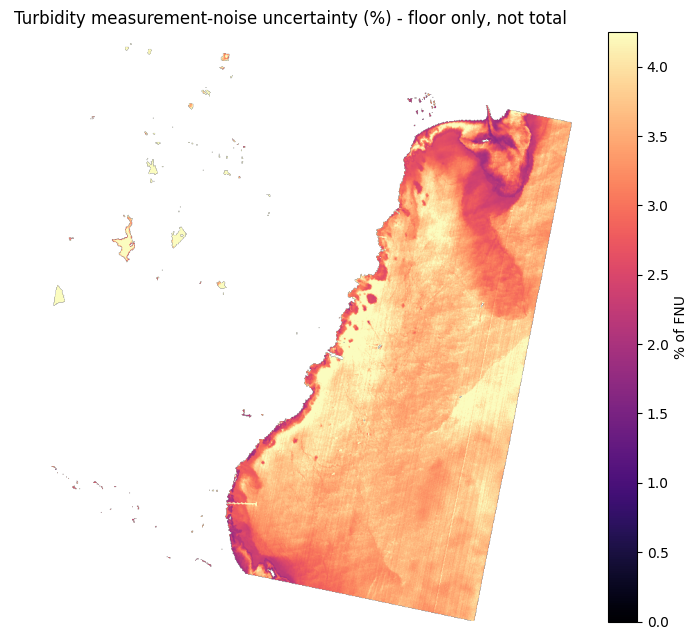

saved -> figures/04_fnu_uncertainty.png


In [5]:
rr = np.clip(rho_red_c, 0, 0.9 * C_RED); rn = np.clip(rho_nir_c, 0, 0.9 * C_NIR)
dT_red = A_RED / (1 - rr / C_RED) ** 2
dT_nir = A_NIR / (1 - rn / C_NIR) ** 2
sigma_T = np.sqrt(((1 - w_nir) * dT_red * un_red) ** 2 + (w_nir * dT_nir * un_nir) ** 2)
rel_unc = np.where(water & ~saturated, 100 * sigma_T / np.maximum(turbidity, 1e-6), np.nan)

print(f"Planet reflectance uncertainty (red), median over water: {np.nanmedian(un_red[water]):.4f}")
print(f"-> turbidity measurement-noise uncertainty: median {np.nanmedian(rel_unc[water]):.0f}% "
      f"(NOTE: excludes the much larger coefficient + atmospheric-correction error)")

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(rel_unc, cmap="magma", vmin=0, vmax=np.nanpercentile(rel_unc[water & ~saturated], 95))
ax.set_title("Turbidity measurement-noise uncertainty (%) - floor only, not total"); ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, label="% of FNU")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_fnu_uncertainty.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "04_fnu_uncertainty.png")


## 5. Checks and transect

The checks compare the FNU range with coastal-water literature, test rank agreement with the
relative turbidity map from Notebook 03, and plot a river-to-offshore transect in FNU.


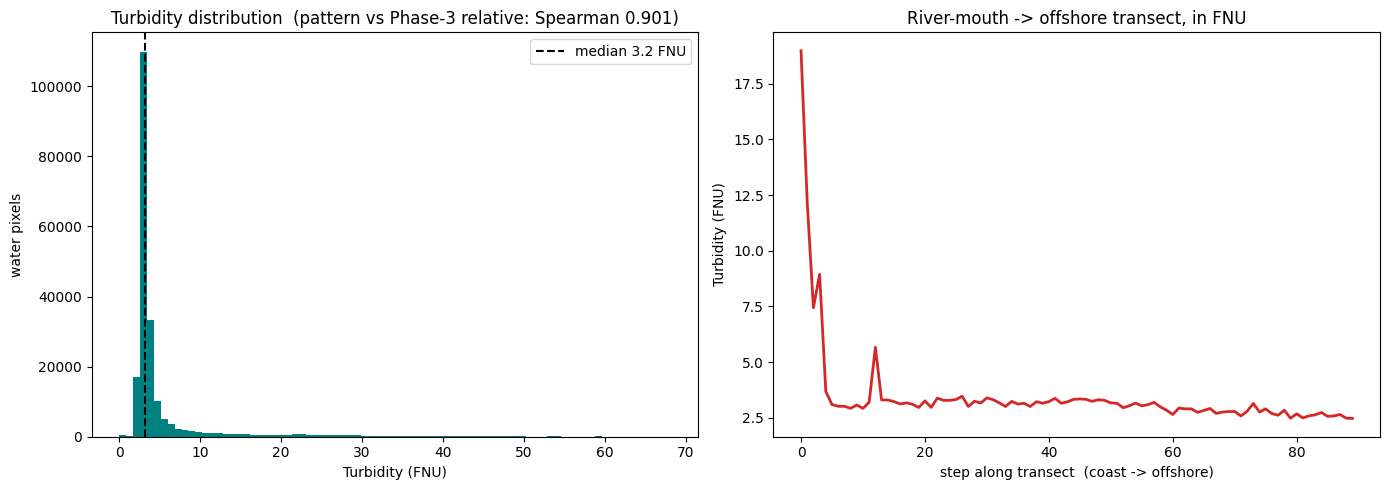

pattern agreement with Phase-3 relative turbidity: Spearman = 0.901
saved -> figures/04_transect_fnu.png


In [6]:
# Phase-3 relative turbidity (red-band Nechad form, C=0.25) for the pattern comparison
rel3 = wonly(rho_red / (1 - rho_red / 0.25))
m = np.isfinite(turb) & np.isfinite(rel3)
rho_s = spearmanr(turb[m], rel3[m]).statistic

start, end = (420, 480), (420, 780)
rows = np.linspace(start[0], end[0], 100).round().astype(int)
cols = np.linspace(start[1], end[1], 100).round().astype(int)
prof = turb[rows, cols]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(v[v < np.percentile(v, 99)], bins=80, color="teal")
ax[0].axvline(np.median(v), color="k", ls="--", label=f"median {np.median(v):.1f} FNU")
ax[0].set_xlabel("Turbidity (FNU)"); ax[0].set_ylabel("water pixels")
ax[0].set_title(f"Turbidity distribution  (pattern vs Phase-3 relative: Spearman {rho_s:.3f})"); ax[0].legend()
ax[1].plot(np.arange(100), prof, "C3", lw=2)
ax[1].set_xlabel("step along transect  (coast -> offshore)"); ax[1].set_ylabel("Turbidity (FNU)")
ax[1].set_title("River-mouth -> offshore transect, in FNU")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_transect_fnu.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"pattern agreement with Phase-3 relative turbidity: Spearman = {rho_s:.3f}")
print("saved ->", FIG_DIR / "04_transect_fnu.png")


## Summary

Notebook 04 produces a quasi-absolute turbidity map in FNU using the published Nechad/Dogliotti
method. The spatial pattern and order of magnitude are the main results. Exact values remain
uncertain because the coefficients are generic, the atmospheric correction is land-based, and
there are no local measurements.

**Figures:** `04_resampled_bands.png`, `04_turbidity_fnu.png`, `04_fnu_uncertainty.png`,
`04_transect_fnu.png`.

Future improvements are water-specific atmospheric correction, real-unit chlorophyll and
suspended-sediment retrievals, and comparison with near-coincident Sentinel-2 or Sentinel-3 data.
